In [1]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import joblib, os

MODEL_DIR  = os.path.abspath(os.path.join(os.getcwd(),'..','models'))
PLOT_DIR   = os.path.abspath(os.path.join(os.getcwd(),'..','outputs','plots'))
REPORT_DIR = os.path.abspath(os.path.join(os.getcwd(),'..','outputs','reports'))

xgb_model = joblib.load(os.path.join(MODEL_DIR,'xgboost_model.pkl'))
test_data  = joblib.load(os.path.join(MODEL_DIR,'test_data.pkl'))

X_train = test_data['X_train']
X_test  = test_data['X_test']
y_train = test_data['y_train']
y_test  = test_data['y_test']

print("Data loaded successfully")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Data loaded successfully
Train: (41015, 33) | Test: (8790, 33)


In [2]:
# Cell 2 — Define all baseline models
baseline_models = {
    'Decision Tree'     : DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'       : GaussianNB(),
}
print("Baseline models defined")

Baseline models defined


In [3]:
# Cell 3 — Train and evaluate all models
results = {}

for name, model in baseline_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results[name] = {
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred)*100, 4),
        'Precision (%)' : round(precision_score(y_test, y_pred)*100, 4),
        'Recall (%)'    : round(recall_score(y_test, y_pred)*100, 4),
        'F1-Score (%)'  : round(f1_score(y_test, y_pred)*100, 4),
        'ROC-AUC'       : round(roc_auc_score(y_test, y_prob), 4),
    }

# Add XGBoost (your model)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

results['XGBoost + DRES (Ours)'] = {
    'Accuracy (%)'  : round(accuracy_score(y_test, y_pred_xgb)*100, 4),
    'Precision (%)' : round(precision_score(y_test, y_pred_xgb)*100, 4),
    'Recall (%)'    : round(recall_score(y_test, y_pred_xgb)*100, 4),
    'F1-Score (%)'  : round(f1_score(y_test, y_pred_xgb)*100, 4),
    'ROC-AUC'       : round(roc_auc_score(y_test, y_prob_xgb), 4),
}

results_df = pd.DataFrame(results).T
print("\n" + "="*65)
print("      BASELINE COMPARISON RESULTS TABLE")
print("="*65)
print(results_df.to_string())

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Naive Bayes...

      BASELINE COMPARISON RESULTS TABLE
                       Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC
Decision Tree               99.9317        99.8637    100.0000       99.9318   0.9993
Random Forest               99.9659        99.9318    100.0000       99.9659   1.0000
Gradient Boosting           99.9772        99.9545    100.0000       99.9773   1.0000
Naive Bayes                 99.1581        98.6490     99.6815       99.1625   0.9936
XGBoost + DRES (Ours)       99.9772        99.9545    100.0000       99.9773   1.0000


C:\Users\aryar\AppData\Local\Temp\ipykernel_39444\4077998126.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models, rotation=20, ha='right', fontsize=9)
C:\Users\aryar\AppData\Local\Temp\ipykernel_39444\4077998126.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=20, ha='right', fontsize=9)


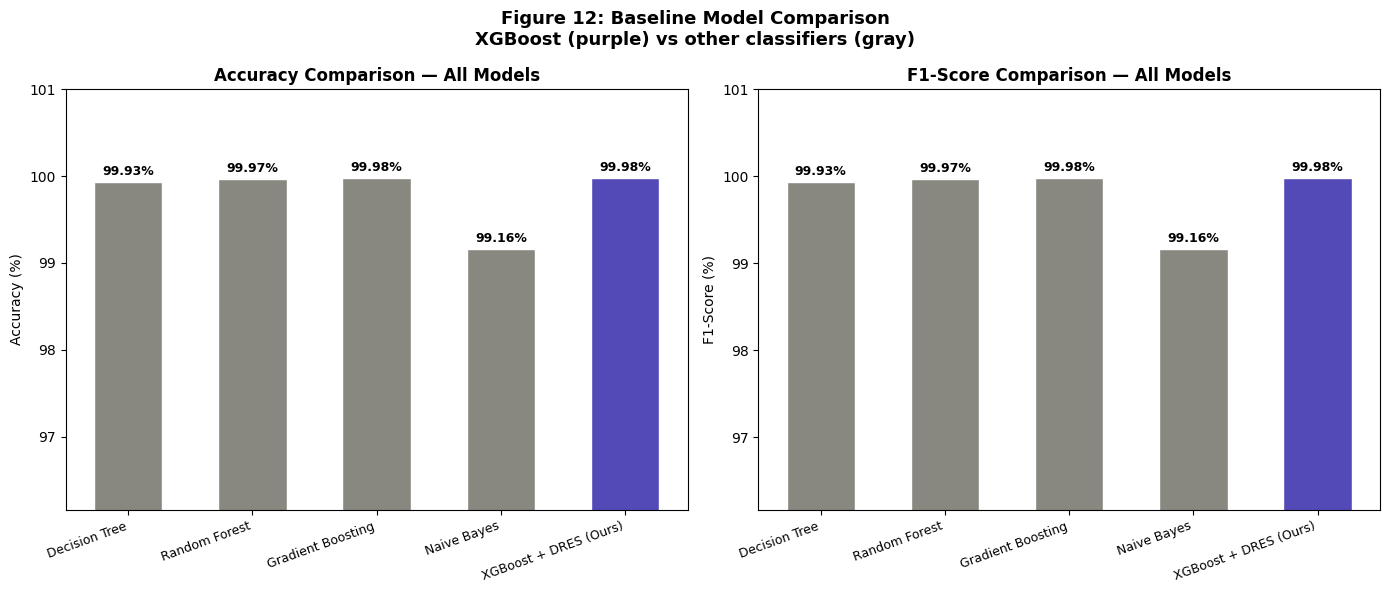

Saved: fig12_baseline_comparison.png


NameError: name 'python' is not defined

In [4]:
# Cell 4 — Plot comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics   = ['Accuracy (%)','F1-Score (%)','Precision (%)','Recall (%)']
models    = results_df.index.tolist()
colors    = ['#888780','#888780','#888780','#888780','#534AB7']

# Accuracy comparison
acc_vals = results_df['Accuracy (%)'].values
bars = axes[0].bar(models, acc_vals, color=colors,
                   edgecolor='white', width=0.55)
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.05,
                 f'{val:.2f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Comparison — All Models', fontweight='bold')
axes[0].set_xticklabels(models, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim([results_df['Accuracy (%)'].min()-3, 101])

# F1-Score comparison
f1_vals = results_df['F1-Score (%)'].values
bars2 = axes[1].bar(models, f1_vals, color=colors,
                    edgecolor='white', width=0.55)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.05,
                 f'{val:.2f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_title('F1-Score Comparison — All Models', fontweight='bold')
axes[1].set_xticklabels(models, rotation=20, ha='right', fontsize=9)
axes[1].set_ylim([results_df['F1-Score (%)'].min()-3, 101])

plt.suptitle('Figure 12: Baseline Model Comparison\n'
             'XGBoost (purple) vs other classifiers (gray)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,'fig12_baseline_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig12_baseline_comparison.png")
python# Cell 5 — Save results table
results_df.to_csv(os.path.join(REPORT_DIR,'baseline_comparison.csv'))
print("Saved: baseline_comparison.csv")
print("\nFINAL VERDICT:")
best = results_df['Accuracy (%)'].idxmax()
print(f"  Best model by Accuracy : {best}")
best_f1 = results_df['F1-Score (%)'].idxmax()
print(f"  Best model by F1-Score : {best_f1}")
print("\nNotebook 10 complete — coding implementation 100% done!")